<a href="https://colab.research.google.com/github/cagg991010/Introduccion-Ing-Datos/blob/main/notebooks/TP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importar librerías

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import io
import zipfile # Tabajar con archivos comprimidos (zip, por ejemplo)
import requests # Realizar peticiones HTTP
from concurrent.futures import ThreadPoolExecutor # Ejecutar varias tareas al mismo tiempo (Optimizar)

# Funciones

In [ ]:
# Función para procesar archivo
def procesar_archivo_gdelt(url):
    """
    Descarga, descomprime en RAM y lee únicamente las 3 columnas necesarias
    de un archivo de eventos de GDELT.
    """
    try:
        res = requests.get(url, timeout=15)
        if res.status_code == 200:
            with zipfile.ZipFile(io.BytesIO(res.content)) as zip_ref:
                # Get the name of the CSV file inside the zip archive
                nombre_csv = zip_ref.namelist()[0]
                with zip_ref.open(nombre_csv) as archivo_csv:
                    # Se leen solo las columnas 1 (Day), 32 (NumSources) y 33 (NumArticles) (0-indexed values)
                    df = pd.read_csv(
                        archivo_csv,
                        sep='\t',
                        header=None,
                        usecols=[1, 32, 33],
                        names=['Day', 'NumSources', 'NumArticles'],
                        dtype={'Day': str, 'NumSources': 'float64', 'NumArticles': 'float64'}
                    )
                    return df
        else:
            # Información
            print(f"No se pudo descargar {url} con el código de estado {res.status_code}")
            return None
    except Exception as e:
        print(f"Error en el procesamiento {url}: {e}")
        return None

# Desarrollo

In [ ]:
# Descargar la lista maestra de archivos de GDELT 2.0
url_master = 'https://data.gdeltproject.org/gdeltv2/masterfilelist.txt' # Dirección del sitio
respuesta = requests.get(url_master) # Ve a esta dirección y traiga la información
lineas = respuesta.text.strip().split('\n') # Obtener el contenido del archivo como texto, eliminar espacios en blanco y hacer salto de línea

# Tomar únicamente los archivos .export.CSV.zip creados a partir del 2 Sep 2026
fecha_inicio_proceso = '20260902' # Equivale al 2-sep-2026, tiempo en segundos acumulados
urls_export = [] # Lista vacía, vamos a ir guardando urls que cumplan con los parámetros

for linea in lineas: # Recorrer todas las líneas
    partes = linea.split() # Crear una lista en cada línea, para tomar índices
    if len(partes) == 3:
        url = partes[2] # Tomar el índice en el que está la url
        if ".export.CSV.zip" in url: # Comprobar si .export.CSV.zip está en la url
            nombre_archivo = url.split('/')[-1] # Obtener el nombre del archivo únicamente
            timestamp_archivo = nombre_archivo.split('.') # Obtiene YYYYMMDDHHMMSS

            if timestamp_archivo[0] >= fecha_inicio_proceso: # Comparar si el archivo es del 2 de septiembre en adelante
                urls_export.append(url)

print(f"Total de archivos de 15 minutos identificados para descargar: {len(urls_export)}")

Total de archivos de 15 minutos identificados para descargar: 1345


In [ ]:
# Procesamiento multihilo paralelo
lista_dataframes = []

with ThreadPoolExecutor(max_workers=10) as executor:
    resultados = executor.map(procesar_archivo_gdelt, urls_export)
    for df in resultados:
        if df is not None and not df.empty:
            lista_dataframes.append(df)

# Concatenar todos los DataFrames extraídos
# Comprobar si lista_dataframes está vacía antes de concatenar
if lista_dataframes:
    df_bruto = pd.concat(lista_dataframes, ignore_index=True)
    print(f"Total de registros de eventos leídos: {len(df_bruto):,}")
else:
    print("No se pudieron cargar datos. La lista de DataFrames está vacía.")
    df_bruto = pd.DataFrame(columns=['Day', 'NumSources', 'NumArticles']) # Crear un DataFrame vacío para evitar errores posteriores

Total de registros de eventos leídos: 1,375,335


In [ ]:
# Filtrar explícitamente la columna Day para restringir eventos entre el 2 y el 15 de Sep 2026
df_filtrado = df_bruto[(df_bruto['Day'] >= '20260902') & (df_bruto['Day'] <= '20260915')].copy()

# Agrupar por la columna Day y calcular las medidas solicitadas
df_resultado = df_filtrado.groupby('Day').agg(
    Cantidad_Eventos=('Day', 'count'),
    Promedio_Articulos_Por_Evento=('NumArticles', 'mean'),
    Promedio_Fuentes_Por_Evento=('NumSources', 'mean')
).reset_index()

# Renombrar columna y redondear métricas a 2 decimales
df_resultado.rename(columns={'Day': 'Fecha'}, inplace=True)
df_resultado['Promedio_Articulos_Por_Evento'] = df_resultado['Promedio_Articulos_Por_Evento'].round(2)
df_resultado['Promedio_Fuentes_Por_Evento'] = df_resultado['Promedio_Fuentes_Por_Evento'].round(2)

# Presentación final del DataFrame de Pandas
print(df_resultado)

,Fecha,Cantidad_Eventos,Promedio_Articulos_Por_Evento,Promedio_Fuentes_Por_Evento
0,20260902,118700,4.64,1.05
1,20260903,115359,4.64,1.05
2,20260904,105533,4.69,1.05
3,20260905,66166,4.65,1.04
4,20260906,59949,4.58,1.04
5,20260907,85510,4.68,1.04
6,20260908,113931,4.61,1.05
7,20260909,117050,4.63,1.04
8,20260910,115806,4.60,1.04
9,20260911,113780,4.57,1.04


# Información complementaria

In [ ]:
print(df_resultado.describe()) # Estadística descriptiva
print(df.info()) # Información

       Cantidad_Eventos  Promedio_Articulos_Por_Evento  \
count         14.000000                      14.000000   
mean       96833.500000                       4.609286   
std        22700.678549                       0.063545   
min        59748.000000                       4.480000   
25%        77732.500000                       4.580000   
50%       107785.000000                       4.620000   
75%       115002.000000                       4.647500   
max       118700.000000                       4.690000   

       Promedio_Fuentes_Por_Evento  
count                    14.000000  
mean                      1.045000  
std                       0.006504  
min                       1.040000  
25%                       1.040000  
50%                       1.040000  
75%                       1.050000  
max                       1.060000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1272 entries, 0 to 1271
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtyp

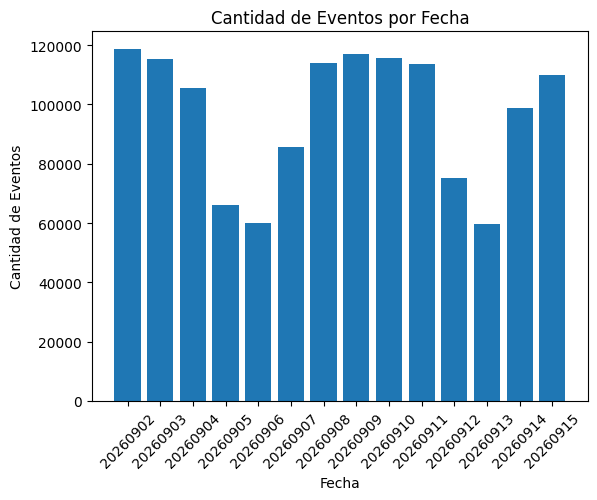

In [ ]:
plt.bar(df_resultado['Fecha'], df_resultado['Cantidad_Eventos'])
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Eventos')
plt.title('Cantidad de Eventos por Fecha')
plt.xticks(rotation=45)
plt.show()

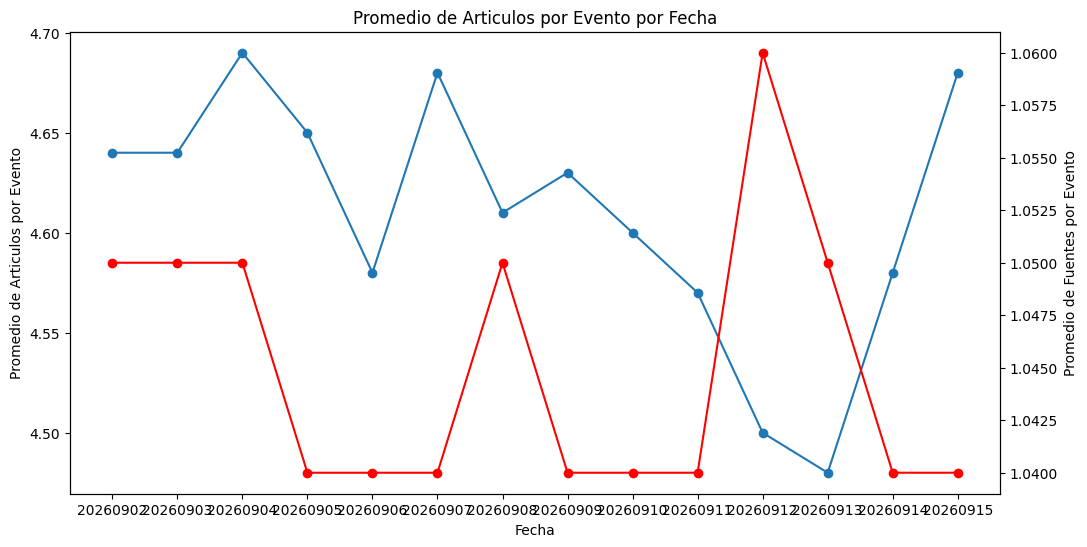

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df_resultado['Fecha'], df_resultado['Promedio_Articulos_Por_Evento'], marker='o')
plt.xlabel('Fecha')
plt.ylabel('Promedio de Articulos por Evento')
plt.title('Promedio de Articulos por Evento por Fecha')

ax = plt.twinx()
ax.plot(df_resultado['Fecha'], df_resultado['Promedio_Fuentes_Por_Evento'], color='red', marker='o')
ax.set_ylabel('Promedio de Fuentes por Evento')

plt.show()